In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/9
    print("準備完了！このまま下のセルを実行できます。")

# 第9章 正則化 (Regularization)
## 9.1 帰納バイアス (Inductive Bias)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第9章「正則化」第9.1節「帰納バイアス」の完全解説、数式導出、および図版再現 (Figure 9.1, Figure 9.2) を提供します。

---

### 目次
1. **9.1.1 逆問題 (Inverse Problems)**
   - 機械学習が本質的に不適切（Ill-posed）な逆問題である理由
   - 解空間を制約する帰納バイアス（事前知識）
   - 平滑性（Smoothness）の優先と正則化項 $\frac{\lambda}{2} \mathbf{w}^T \mathbf{w}$ (式 9.1)
2. **9.1.2 ノーフリーランチ定理 (No Free Lunch Theorem)**
   - Wolpert (1996) によるノーフリーランチ定理の数学的意味
   - 実世界データが占める構造化部分多様体と帰納バイアスの必然性
3. **9.1.3 対称性と不変性 (Symmetry and Invariance)**
   - 群論（Group Theory）の公理：閉包性・結合律・単位元・逆元
   - 離散群の例：巡回群 $C_4$ と二面体群 $D_4$
   - 不変性を組み込む4つのアプローチ（特徴抽出・正則化/接線伝播・データ拡張・ネットワーク構造）
   - **Figure 9.1 再現**: データセット拡張の8つの canonical 変換
   - 入力への微小ノイズ付加と入力勾配正則化の期待値等価性（Bishop, 1995c）
4. **9.1.4 等変性 (Equivariance)**
   - 等変性の定義：$\mathcal{S}(\mathcal{T}(I)) = \mathcal{T}(\mathcal{S}(I))$ (式 9.2)
   - 一般化等変性：$\mathcal{S}(\mathcal{T}(I)) = \widetilde{\mathcal{T}}(\mathcal{S}(I))$ (式 9.3)
   - 不変性の特殊ケースとしての位置づけ：$\mathcal{C}(\mathcal{T}(I)) = \mathcal{C}(I)$ (式 9.4)
   - **Figure 9.2 再現**: 等変性の可換図式（Commutative Diagram）


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# プロジェクトルートの設定
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style
from common.inductive_bias import (
    fit_polynomial_regression,
    compute_smoothness_norm,
    simulate_no_free_lunch,
    create_cyclic_group_c4,
    create_dihedral_group_d4,
    verify_noise_gradient_regularization_equivalence,
    translate_image,
    segment_silhouette,
    verify_equivariance_property,
    generate_figure_9_1,
    generate_figure_9_2,
)

setup_style()
print("Setup completed successfully.")


Setup completed successfully.


---
## 9.1.1 逆問題 (Inverse Problems)

機械学習におけるモデル選択の中心的な課題は、大半のタスクが**逆問題 (Inverse problem)** であるという事実に起因します。

### 順問題と逆問題の非対称性
- **順問題 (Forward problem)**: 真の条件付き分布 $p(t|\mathbf{x})$ と有限個の入力標本 $\{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ が与えられたとき、それらに対応する目標値 $\{t_1, \dots, t_N\}$ を生成することは原理的に一意かつ容易です。
- **逆問題 (Inverse problem)**: 観測された有限個の標本対 $\{(\mathbf{x}_n, t_n)\}_{n=1}^N$ のみから、入力空間全体における連続的な分布 $p(t|\mathbf{x})$ や回帰関数 $y(\mathbf{x})$ 全体を復元すること。

この逆問題は本質的に**不良設定問題（Ill-posed problem）** です。なぜなら、観測データを完璧に補間できる関数 $y(\mathbf{x})$ は無限に存在し、観測点において正の確率密度をもつ分布はすべて候補になり得るからです。

### 帰納バイアス（Prior Knowledge）の役割
新しい入力値 $\mathbf{x}_{\text{new}}$ に対する予測（汎化）を可能にするためには、無数に存在する候補の中から特定の関数を優遇・選抜する**選好基準**が必要となります。この選好や前提知識を**帰納バイアス (Inductive bias)** と呼びます。

最も代表的な帰納バイアスは「平滑性（Smoothness）」です：
「入力 $\mathbf{x}$ が微小に変化したとき、出力 $y$ も緩やかに変化するべきである」
この事前知識は、式 (9.1) に示すパラメータの $L_2$ 正則化（Weight Decay）によって明示的に導入されます：
$$\widetilde{E}(\mathbf{w}) = E(\mathbf{w}) + \frac{\lambda}{2} \mathbf{w}^T \mathbf{w} \quad (9.1)$$
正則化係数 $\lambda$ を適切に選定することで、モデルの分散（過学習）を抑制し、有限データからの優れた汎化性能を実現します。


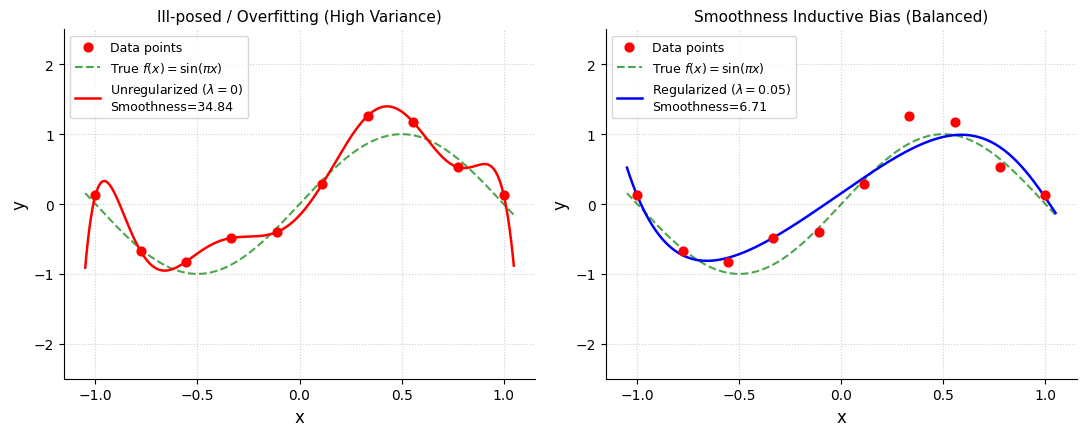

Norm of unregularized weights: 84.25
Norm of regularized weights:   2.54
Smoothness reduction factor:   5.19x


In [2]:
# 逆問題の不良設定性と正則化による平滑性バイアスの効果
rng = np.random.RandomState(42)
N = 10
x_train = np.linspace(-1, 1, N)
t_true = np.sin(np.pi * x_train)
t_train = t_true + rng.randn(N) * 0.25

# 高次多項式 (M=9) のフィッティング: 非正則化 vs 正則化
w_unreg, fn_unreg = fit_polynomial_regression(x_train, t_train, degree=9, reg_lambda=0.0)
w_reg, fn_reg = fit_polynomial_regression(x_train, t_train, degree=9, reg_lambda=0.05)

x_plot = np.linspace(-1.05, 1.05, 300)
smooth_unreg = compute_smoothness_norm(fn_unreg, x_plot)
smooth_reg = compute_smoothness_norm(fn_reg, x_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Unregularized
ax1.scatter(x_train, t_train, color="red", s=40, zorder=4, label="Data points")
ax1.plot(x_plot, np.sin(np.pi * x_plot), "g--", alpha=0.7, label=r"True $f(x)=\sin(\pi x)$")
ax1.plot(x_plot, fn_unreg(x_plot), "r-", lw=1.8, label=f"Unregularized ($\lambda=0$)\nSmoothness={smooth_unreg:.2f}")
ax1.set_ylim(-2.5, 2.5)
ax1.set_title("Ill-posed / Overfitting (High Variance)", fontsize=11)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(frameon=True, fontsize=9)
ax1.grid(True, linestyle=":", alpha=0.6)

# Regularized
ax2.scatter(x_train, t_train, color="red", s=40, zorder=4, label="Data points")
ax2.plot(x_plot, np.sin(np.pi * x_plot), "g--", alpha=0.7, label=r"True $f(x)=\sin(\pi x)$")
ax2.plot(x_plot, fn_reg(x_plot), "b-", lw=1.8, label=f"Regularized ($\lambda=0.05$)\nSmoothness={smooth_reg:.2f}")
ax2.set_ylim(-2.5, 2.5)
ax2.set_title("Smoothness Inductive Bias (Balanced)", fontsize=11)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend(frameon=True, fontsize=9)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Norm of unregularized weights: {np.linalg.norm(w_unreg):.2f}")
print(f"Norm of regularized weights:   {np.linalg.norm(w_reg):.2f}")
print(f"Smoothness reduction factor:   {smooth_unreg / smooth_reg:.2f}x")


---
## 9.1.2 ノーフリーランチ定理 (No Free Lunch Theorem)

深層ニューラルネットワークは極めて表現力が高く、画像認識・音声・自然言語処理などの多様な分野で革命的な成果を収めています。一見すると「あらゆる問題を解決できる万能の学習器」であるかのように見えますが、数学的にはいかなる学習器も**ノーフリーランチ定理**に従います。

### Wolpert (1996) のノーフリーランチ定理
> **「数学的に考え得るすべての問題の空間上で一様に平均をとると、あらゆる学習アルゴリズムの性能は完全に同一（無作為抽出と同等）である。」**

もしあるアルゴリズム $A$ が特定の問題群において優れた汎化性能を示すならば、それは他の同等の問題群において平均以下に劣っていなければなりません。

### なぜ深層学習は実世界で成功するのか？
ノーフリーランチ定理が対象とする「すべての問題の空間」には、近傍の画素が全く無相関でノイズのように激しく振動するような、現実にはあり得ない極端な関数が大部分を占めています。
現実世界で遭遇する実用的な問題は、宇宙の物理法則や知覚の連続性により、以下の強力な幾何学的構造をもつ**ごくわずかな部分多様体（Sub-manifold）** に局在しています：
1. **平滑性 (Smoothness)**: 近い入力は近い出力を持つ。
2. **空間的局所性 (Locality)**: 隣接するピクセルや音声フレームは高い相関を持つ。
3. **対称性と等変性 (Symmetry & Equivariance)**: 物体の位置や向きが変わっても物体の本質は変わらない。

深層学習のアーキテクチャ（CNNやTransformer等）は、まさにこれらの実世界の構造に合致した強力な帰納バイアスを明示的・暗黙的に組み込んでいるからこそ、高い汎化性能を発揮できるのです。


In [3]:
# ノーフリーランチ定理の厳密な離散有限集合シミュレーション
nfl_res = simulate_no_free_lunch(num_inputs=6, num_train=3)
print("No Free Lunch Theorem Numerical Verification:")
print(f"  Number of possible unseen function completions: {nfl_res['num_completions']}")
print(f"  Algorithm A (All 0s) Average Generalization Error:  {nfl_res['avg_error_A']:.6f} (50.0%)")
print(f"  Algorithm B (All 1s) Average Generalization Error:  {nfl_res['avg_error_B']:.6f} (50.0%)")
print(f"  Algorithm C (Parity) Average Generalization Error:  {nfl_res['avg_error_C']:.6f} (50.0%)")
print(f"  Theorem strictly verified: {nfl_res['nfl_verified']}")


No Free Lunch Theorem Numerical Verification:
  Number of possible unseen function completions: 8
  Algorithm A (All 0s) Average Generalization Error:  0.500000 (50.0%)
  Algorithm B (All 1s) Average Generalization Error:  0.500000 (50.0%)
  Algorithm C (Parity) Average Generalization Error:  0.500000 (50.0%)
  Theorem strictly verified: True


---
## 9.1.3 対称性と不変性 (Symmetry and Invariance)

多くの実世界タスクにおいて、入力変数のある種の変換に対して予測結果が変化しない（**不変である (Invariant)**）ことが要求されます。
- 例：画像中の猫の分類において、猫の位置が変わっても（平行移動不変性）、大きさが変わっても（スケール不変性）、同じ「猫」と判定されなければならない。

### 群論 (Group Theory) の数学的基礎
ある性質を不変に保つ変換の集合は、数学的な**群（Group）** の構造を形成します。
群 $(G, \circ)$ は、集合 $G$ と二項演算 $\circ$ の組であり、以下の4つの公理をすべて満たします：
1. **閉包性 (Closure)**: 任意の $A, B \in G$ に対し、$A \circ B \in G$。
2. **結合律 (Associativity)**: 任意の $A, B, C \in G$ に対し、$(A \circ B) \circ C = A \circ (B \circ C)$。
3. **単位元 (Identity)**: ある元 $I \in G$ が存在し、任意の $A \in G$ に対し $A \circ I = I \circ A = A$。
4. **逆元 (Inverse)**: 各 $A \in G$ に対し、ある元 $A^{-1} \in G$ が存在し、$A \circ A^{-1} = A^{-1} \circ A = I$。

代表的な幾何学的群：
- 正方形の $90^\circ$ 刻みの回転群：巡回群 $C_4$
- 正方形の回転と鏡映（裏返し）の群：二面体群 $D_4$（位数 8）
- 2次元平面における連続平行移動群 $T(2)$、回転群 $SO(2)$、ユークリッド合同変換群 $SE(2)$

### 不変性を学習器に組み込む4つのアプローチ
モデルに不変性をもたせる方法には、主に以下の4つの分類があります：
1. **特徴前処理 (Pre-processing)**: 入力データから不変な特徴量をあらかじめ抽出し、それをモデルの入力とする。
2. **誤差関数の正則化 (Regularized error function)**: 変換による出力の変化にペナルティを課す（例：接線伝播 Tangent Propagation, Simard et al., 1992）。
3. **データセット拡張 (Data augmentation)**: 訓練データを意図的に変換した複製を大量に生成し、データ側で不変性を学習させる。
4. **ネットワーク構造の設計 (Network architecture)**: 重み共有やプーリングなど、ネットワークの計算構造自体に不変性を組み込む（例：CNN）。


In [4]:
# 群論の公理の数値検証: 巡回群 C_4 および 二面体群 D_4
c4 = create_cyclic_group_c4()
axioms_c4 = c4.verify_axioms()
print(f"Group C_4 (Rotations of a square, order {len(c4.elements)}):")
for ax_name, val in axioms_c4.items():
    print(f"  {ax_name:15s}: {val}")

d4 = create_dihedral_group_d4()
axioms_d4 = d4.verify_axioms()
print(f"\nGroup D_4 (Symmetries of a square, order {len(d4.elements)}):")
for ax_name, val in axioms_d4.items():
    print(f"  {ax_name:15s}: {val}")


Group C_4 (Rotations of a square, order 4):
  closure        : True
  associativity  : True
  identity       : True
  inverse        : True
  is_valid_group : True

Group D_4 (Symmetries of a square, order 8):
  closure        : True
  associativity  : True
  identity       : True
  inverse        : True
  is_valid_group : True


### Figure 9.1: データセット拡張 (Data Set Augmentation)

アプローチ3の**データセット拡張**は、画像処理において最も標準的かつ効果的な正則化手法の1つです。
Figure 9.1 では、猫の元画像に対して適用される代表的な8つの幾何学的・測光学的変換を示します：
- (a) 原画像 (Original image)
- (b) 左右反転 (Horizontal inversion)
- (c) スケーリング (Scaling / Zoom)
- (d) 平行移動 (Translation)
- (e) 回転 (Rotation)
- (f) 明度・コントラスト変更 (Brightness and contrast change)
- (g) 加法的ノイズ (Additive Gaussian noise)
- (h) 色相シフト (Colour shift)


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_1_data_augmentation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_1_data_augmentation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_1.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_1.png


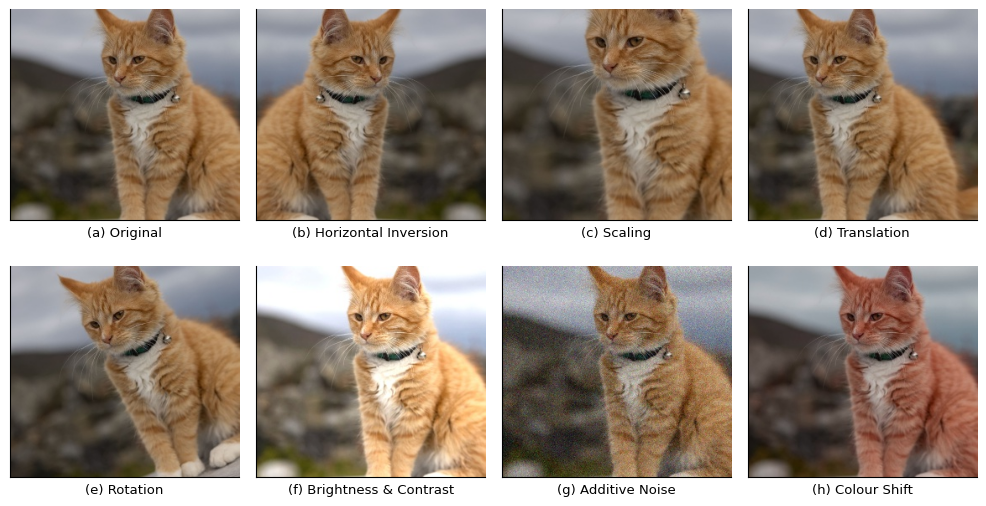

Figure 9.1 reproduced and saved successfully.


In [5]:
# Figure 9.1 の生成と保存
fig_9_1 = generate_figure_9_1(save_both=True)
plt.show()
print("Figure 9.1 reproduced and saved successfully.")


### 入力ノイズ付加と入力勾配正則化の数学的等価性 (Bishop, 1995c)

訓練データに加法的な微小ガウスノイズ $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$ を加えて学習させるデータ拡張（Figure 9.1g）は、解析的に**モデルの入力勾配ノルム $\|\nabla_{\mathbf{x}} y(\mathbf{x})\|^2$ に対する正則化ペナルティ**と期待値の意味で厳密に等価であることが証明されています。

#### 数学的証明
入力点 $\mathbf{x}$ に微小ノイズ $\boldsymbol{\epsilon}$ を加えたときのモデル出力 $y(\mathbf{x} + \boldsymbol{\epsilon})$ の2次テイラー展開は：
$$y(\mathbf{x} + \boldsymbol{\epsilon}) = y(\mathbf{x}) + \boldsymbol{\epsilon}^T \nabla_{\mathbf{x}} y(\mathbf{x}) + \frac{1}{2} \boldsymbol{\epsilon}^T \nabla_{\mathbf{x}}^2 y(\mathbf{x}) \boldsymbol{\epsilon} + O(\|\boldsymbol{\epsilon}\|^3)$$
二乗誤差 $E(\mathbf{x} + \boldsymbol{\epsilon}) = \frac{1}{2} (y(\mathbf{x} + \boldsymbol{\epsilon}) - t)^2$ を展開すると：
$$E(\mathbf{x} + \boldsymbol{\epsilon}) = \frac{1}{2} \left[ (y(\mathbf{x}) - t) + \boldsymbol{\epsilon}^T \nabla_{\mathbf{x}} y(\mathbf{x}) + \frac{1}{2} \boldsymbol{\epsilon}^T \nabla_{\mathbf{x}}^2 y(\mathbf{x}) \boldsymbol{\epsilon} \right]^2$$
ノイズ $\boldsymbol{\epsilon}$ に関する期待値 $\mathbb{E}_{\boldsymbol{\epsilon}}[\cdot]$ をとると、$\mathbb{E}[\boldsymbol{\epsilon}] = \mathbf{0}$, $\mathbb{E}[\boldsymbol{\epsilon} \boldsymbol{\epsilon}^T] = \sigma^2 \mathbf{I}$ より：
$$\mathbb{E}_{\boldsymbol{\epsilon}}[E(\mathbf{x} + \boldsymbol{\epsilon})] = \frac{1}{2} (y(\mathbf{x}) - t)^2 + \frac{\sigma^2}{2} \|\nabla_{\mathbf{x}} y(\mathbf{x})\|^2 + \frac{\sigma^2}{2} (y(\mathbf{x}) - t) \text{Tr}(\nabla_{\mathbf{x}}^2 y(\mathbf{x})) + O(\sigma^4)$$
モデルが目標値に近づいて残差 $(y(\mathbf{x}) - t) \approx 0$ となるとき、第3項は無視でき：
$$\mathbb{E}_{\boldsymbol{\epsilon}}[E(\mathbf{x} + \boldsymbol{\epsilon})] \approx E(\mathbf{x}) + \frac{\sigma^2}{2} \|\nabla_{\mathbf{x}} y(\mathbf{x})\|^2$$
となります。すなわち、**入力データに分散 $\sigma^2$ のノイズを加えることは、正則化パラメータ $\lambda = \sigma^2$ をもつチホノフ（Tikhonov）勾配正則化項を誤差関数に付加することと等価**です。


In [6]:
# Bishop (1995c) の定理の数値シミュレーション検証
model_fn = lambda x: np.sin(x[0]) * np.cos(x[1])
grad_fn = lambda x: np.array([np.cos(x[0]) * np.cos(x[1]), -np.sin(x[0]) * np.sin(x[1])])

x0 = np.array([0.5, 0.8])
t0 = model_fn(x0)

noise_thm_res = verify_noise_gradient_regularization_equivalence(
    model_fn, grad_fn, x0, t0, noise_sigma=0.015, num_samples=50000
)

print("Bishop (1995c) Noise-Gradient Regularization Equivalence:")
print(f"  Unperturbed loss E(x):           {noise_thm_res['loss_unperturbed']:.8f}")
print(f"  Monte Carlo Expected Loss:       {noise_thm_res['expected_noisy_loss']:.8f}")
print(f"  Analytical Regularized Loss:     {noise_thm_res['predicted_regularized_loss']:.8f}")
print(f"  Gradient Penalty 0.5*sigma^2*||grad||^2: {noise_thm_res['gradient_penalty_term']:.8f}")
print(f"  Relative difference:             {noise_thm_res['rel_diff']:.4%}")
print(f"  Equivalence verified:            {noise_thm_res['verified']}")


Bishop (1995c) Noise-Gradient Regularization Equivalence:
  Unperturbed loss E(x):           0.00000000
  Monte Carlo Expected Loss:       0.00005578
  Analytical Regularized Loss:     0.00005536
  Gradient Penalty 0.5*sigma^2*||grad||^2: 0.00005536
  Relative difference:             0.7551%
  Equivalence verified:            True


---
## 9.1.4 等変性 (Equivariance)

不変性の極めて重要な一般化概念が**等変性 (Equivariance)** です。

### 定義と数学的定式化
不変性では入力を変換しても出力は不変ですが、タスクによっては**入力が変換されたとき、出力もそれに応じて整合的に変換されるべき**場合があります。

代表例が**画像のセマンティックセグメンテーション（領域分割）** です：
- 入力画像を $I$、セグメンテーション演算子を $\mathcal{S}$ とする。
- 平行移動変換を $\mathcal{T}$ とすると、平行移動した画像のセグメンテーション結果は、元画像のセグメンテーション結果を同じだけ平行移動したものに一致しなければなりません：
$$\mathcal{S}(\mathcal{T}(I)) = \mathcal{T}(\mathcal{S}(I)) \quad (9.2)$$

### 一般化された等変性
入力空間と出力空間で表現形式や解像度が異なる場合、等変性は以下のように一般化されます：
$$\mathcal{S}(\mathcal{T}(I)) = \widetilde{\mathcal{T}}(\mathcal{S}(I)) \quad (9.3)$$
- 例1：セグメンテーション画像の解像度が元画像の $1/4$ である場合、$\mathcal{T}$ が元画像空間での平行移動であれば、$\widetilde{\mathcal{T}}$ は $1/4$ スケールの低解像度空間での平行移動を表します。
- 例2：$\mathcal{S}$ が物体の姿勢角度を推定する関数であり、$\mathcal{T}$ が画像の回転（全ピクセルの非線形変換）である場合、$\widetilde{\mathcal{T}}$ は出力のスカラー角度に対する単純な加算演算となります。

### 不変性との関係
不変性は、出力側の変換 $\widetilde{\mathcal{T}}$ が恒等写像（Identity）である場合の等変性の特殊ケースに他なりません：
$$\mathcal{C}(\mathcal{T}(I)) = \mathcal{C}(I) \quad (9.4)$$


### Figure 9.2: 等変性の可換図式 (Commutative Diagram)

式 (9.2) に対応する等変性の関係は、以下の可換図式として視覚化されます：
$$\begin{array}{ccc}
I & \xrightarrow{\quad \mathcal{T} \quad} & \mathcal{T}(I) \\
\Big\downarrow \mathcal{S} & & \Big\downarrow \mathcal{S} \\
\mathcal{S}(I) & \xrightarrow{\quad \mathcal{T} \quad} & \mathcal{T}(\mathcal{S}(I)) = \mathcal{S}(\mathcal{T}(I))
\end{array}$$

1. **上経路**: 画像 (a) をまず平行移動して (b) とし、それをセグメンテーションして (d) を得る。
2. **下経路**: 画像 (a) をまずセグメンテーションして (c) とし、そのセグメンテーションを平行移動して (d) を得る。
両者の経路は厳密に同一の結果 (d) に到達します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_2_equivariance.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_2_equivariance.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_2.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_2.png


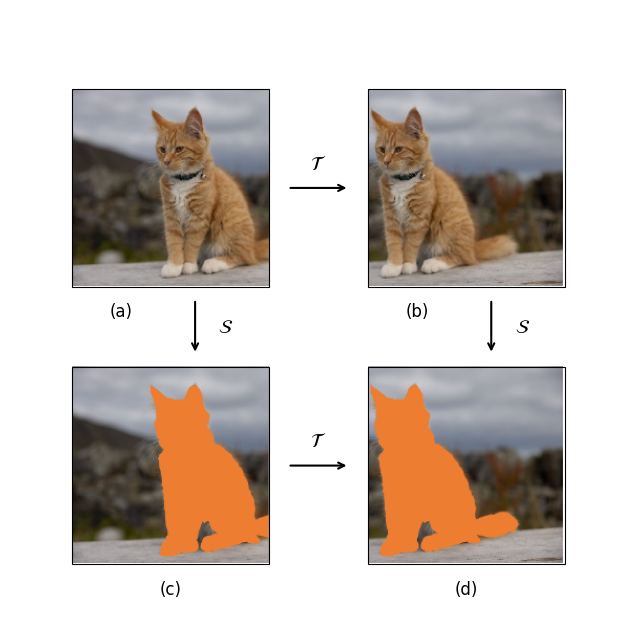

Figure 9.2 reproduced and saved successfully.


In [7]:
# Figure 9.2 の生成と保存
fig_9_2 = generate_figure_9_2(save_both=True)
plt.show()
print("Figure 9.2 reproduced and saved successfully.")


In [8]:
# 実画像に対する等変性可換性の数値検証
im_a = Image.open(os.path.join(project_root, "9", "assets", "fig_9_2_a.png"))
op_T = lambda img: translate_image(img, dx=15, dy=0)
op_S = lambda img: segment_silhouette(img)

eq_res = verify_equivariance_property(im_a, op_T, op_S)
print("Equivariance Numerical Commutativity Check:")
print(f"  Maximum pixel difference |S(T(I)) - T(S(I))|: {eq_res['max_diff']}")
print(f"  Mean pixel difference:                       {eq_res['mean_diff']:.4f}")
print(f"  Commutative property S(T(I)) == T(S(I)):     {eq_res['is_equivariant']}")


Equivariance Numerical Commutativity Check:
  Maximum pixel difference |S(T(I)) - T(S(I))|: 0
  Mean pixel difference:                       0.0000
  Commutative property S(T(I)) == T(S(I)):     True


---
## まとめ

1. **逆問題と帰納バイアス**: 機械学習は有限標本から未知の真の分布を推測する不良設定逆問題であり、平滑性や正則化などの適切な帰納バイアスの導入が汎化に不可欠である。
2. **ノーフリーランチ定理**: あらゆる問題の空間上一様に見れば全てのアルゴリズムは同等であるが、現実世界のデータは強い対称性・平滑性・局所性をもつ部分多様体に局在しているため、それに合致したバイアスをもつ深層学習が成功する。
3. **対称性と不変性**: 変換群の公理を満たす幾何学的対称性に対し、特徴前処理・正則化（接線伝播）・データセット拡張・ネットワーク構造（CNN）の4つの方法で不変性を組み込める。ノイズ付加は入力勾配正則化と期待値的に等価である。
4. **等変性**: 物体の位置変化に応じてセグメンテーション領域も同様に変化するような性質を等変性と呼び、CNNやGNNなどの幾何学的深層学習の根本原理を形成している。
